In [20]:
from scipy.io import loadmat
from numpy import asarray
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpy.matlib
from scipy import signal
from scipy.signal import welch
from scipy.stats import entropy
from scipy.fft import fft, fftfreq
import os
import glob
from warnings import warn
from sklearn import metrics
plt.rc('font',family='Times New Roman')
import warnings 
warnings.filterwarnings('ignore')


In [21]:
# Function to compute FFT:
def apply_fft(x, fs):
    N = len(x) # number of samples in the signal.
    T = 1.0 / fs
    fft_coef = fft(x-np.mean(x)) # Obtain FFT coefficients after removing the mean (DC component) from the signal.
    xf = fftfreq(N, T)[:N//2] # Taking positive spectrum only.
    fft_positve = 2.0/N * np.abs(fft_coef[0:N//2]) # Multiply  abs(FFT coefficients) by 2 to compensate for positive spectrum and normalize by signal length.
    return xf, fft_positve

In [22]:
def make_dataset(data_src):
    files = glob.glob(data_src)
    dataset_df = []
    for file in files:
        dataset_df.append(pd.read_csv(file, header = None))
    dataset = pd.concat(dataset_df, ignore_index=True, axis= 1)
    return dataset.T

In [23]:
# Function to compute PSD

def compute_psd(signal, length, fs):
    seg_length =  length/2 # Segment length.
    overlap = seg_length/3 # overlap between segements (in number of samples)
    nfft_length = 1024 # # FFT length
    frequencies, psd = welch(signal,  fs = fs, window='hann', nperseg= seg_length, noverlap= overlap, nfft= nfft_length)
    
    return frequencies, psd

In [24]:

def spectral_features(signal, fs):
    # Calculate the Power Spectral Density (PSD) using Welch's method
    
    L = len(signal)
    
    frequencies, psd = compute_psd(signal, L,  fs)

    # Normalize the PSD to compute the spectral features correctly
    psd_norm = psd / np.sum(psd)

    # Calculate the Spectral Centroid
    spectral_centroid = np.sum(frequencies * psd_norm)

    # Calculate the Spectral Spread (second central moment)
    spectral_spread = np.sqrt(np.sum(((frequencies - spectral_centroid) ** 2) * psd_norm))
   

    # Calculate the Spectral Entropy
    spectral_entropy = entropy(psd)
    
    peak_freq = frequencies[np.argmax(psd)] # peak freq.
    
    peak_pwr = np.max(psd) # Peak amp.
    

    return spectral_centroid, spectral_spread, spectral_entropy, peak_freq, peak_pwr

==========================================================================================================================
# Dataset Creatioin:
=========================================================================================================================== 

## Grouping vibration signals in required folders to  generate the dataset
 
Link to download the University of Bonn (UoB) EEG dataset dataset: https://www.ukbonn.de/epileptologie/arbeitsgruppen/ag-lehnertz-neurophysik/downloads/ <br>
The EEG signals are grouped according to their operational conditions in 5 folders (A-E): 

A ===>	Z.zip 	
B ===> 	O.zip	
C ===>	N.zip 	
D ===>	F.zip  	
E ===>	S.zip 	

In [27]:
data_path = ("./data/") # path to the 4 folders.
A  = make_dataset(os.path.join(data_path,  'A/*'))
B  = make_dataset(os.path.join(data_path,  'B/*'))
C  = make_dataset(os.path.join(data_path,  'C/*'))
D  = make_dataset(os.path.join(data_path,  'D/*'))
E  = make_dataset(os.path.join(data_path,  'E/*'))

In [28]:
normal = pd.concat([A, B]).reset_index(drop=True).to_numpy()
interictal = pd.concat([C, D]).reset_index(drop=True).to_numpy()
ictal = E.to_numpy()

In [29]:
num_samples =500 # Length of input segment
###########################################
fs =  173.61; # Sampling freq.

In [30]:
# Segmenting EEG signals:

data = normal.reshape(-1)
num_segments = np.floor(len(data)/num_samples)
slices = np.split(data[0:int(num_segments*num_samples)], num_samples)
normal = np.array(slices).reshape(int(num_segments), num_samples)
data = interictal.reshape(-1)
num_segments = np.floor(len(data)/num_samples)
slices = np.split(data[0:int(num_segments*num_samples)], num_samples)
interictal = np.array(slices).reshape(int(num_segments), num_samples)
data = ictal.reshape(-1)
num_segments = np.floor(len(data)/num_samples)
slices = np.split(data[0:int(num_segments*num_samples)], num_samples)
ictal = np.array(slices).reshape(int(num_segments), num_samples)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

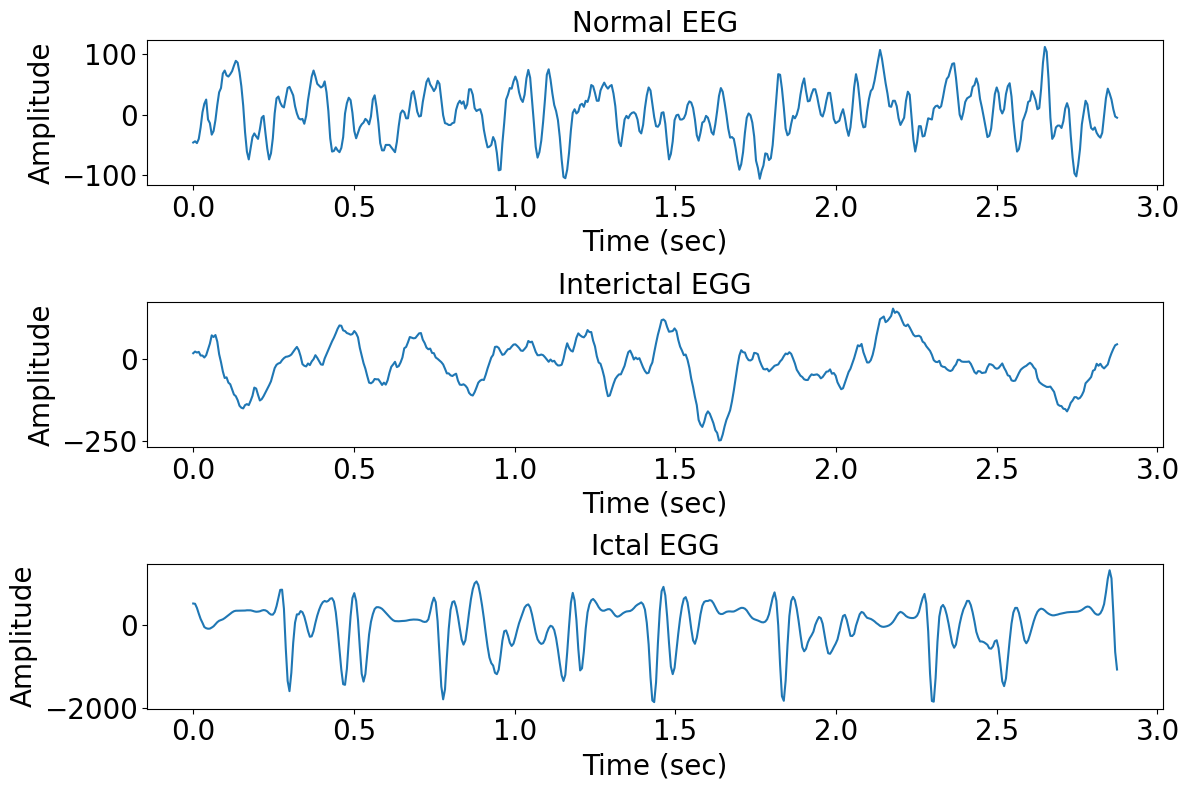

In [31]:
# Sample EEG signals representing the three classes of the UoB dataset.

index = 0

normal_EEG = normal[index]
interictal_EGG = interictal[index]
ictal_EGG = ictal[index]
time = np.arange(0.0, len(normal_EEG), 1.0)/fs
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.tick_params('x', labelsize=20)
plt.tick_params('y', labelsize=20)
plt.plot(time, normal_EEG)
plt.xlabel('Time (sec)', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title("Normal EEG", fontsize = 20)
plt.subplot(3, 1, 2)
plt.tick_params('x', labelsize=20)
plt.tick_params('y', labelsize=20)
plt.plot(time, interictal_EGG)
plt.xlabel('Time (sec)', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title("Interictal EGG", fontsize = 20)
plt.subplot(3, 1, 3)
plt.tick_params('x', labelsize=20)
plt.tick_params('y', labelsize=20)
plt.plot(time, ictal_EGG)
plt.xlabel('Time (sec)', fontsize =20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title("Ictal EGG", fontsize = 20)
plt.tight_layout()
plt.show()

In [32]:
normal_labels = np.zeros(len(normal))
interictal_labels = np.ones(len(interictal))
ictal_labels = np.ones(len(ictal))*2
X = np.concatenate( (normal, interictal, ictal) , axis=0, out=None)
Y = np.concatenate( (normal_labels, interictal_labels, ictal_labels ) , axis=0, out=None)
print("data set features size:", X.shape)
print("data set labels size:", Y.shape)
print(X.shape)

data set features size: (4095, 500)
data set labels size: (4095,)
(4095, 500)


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


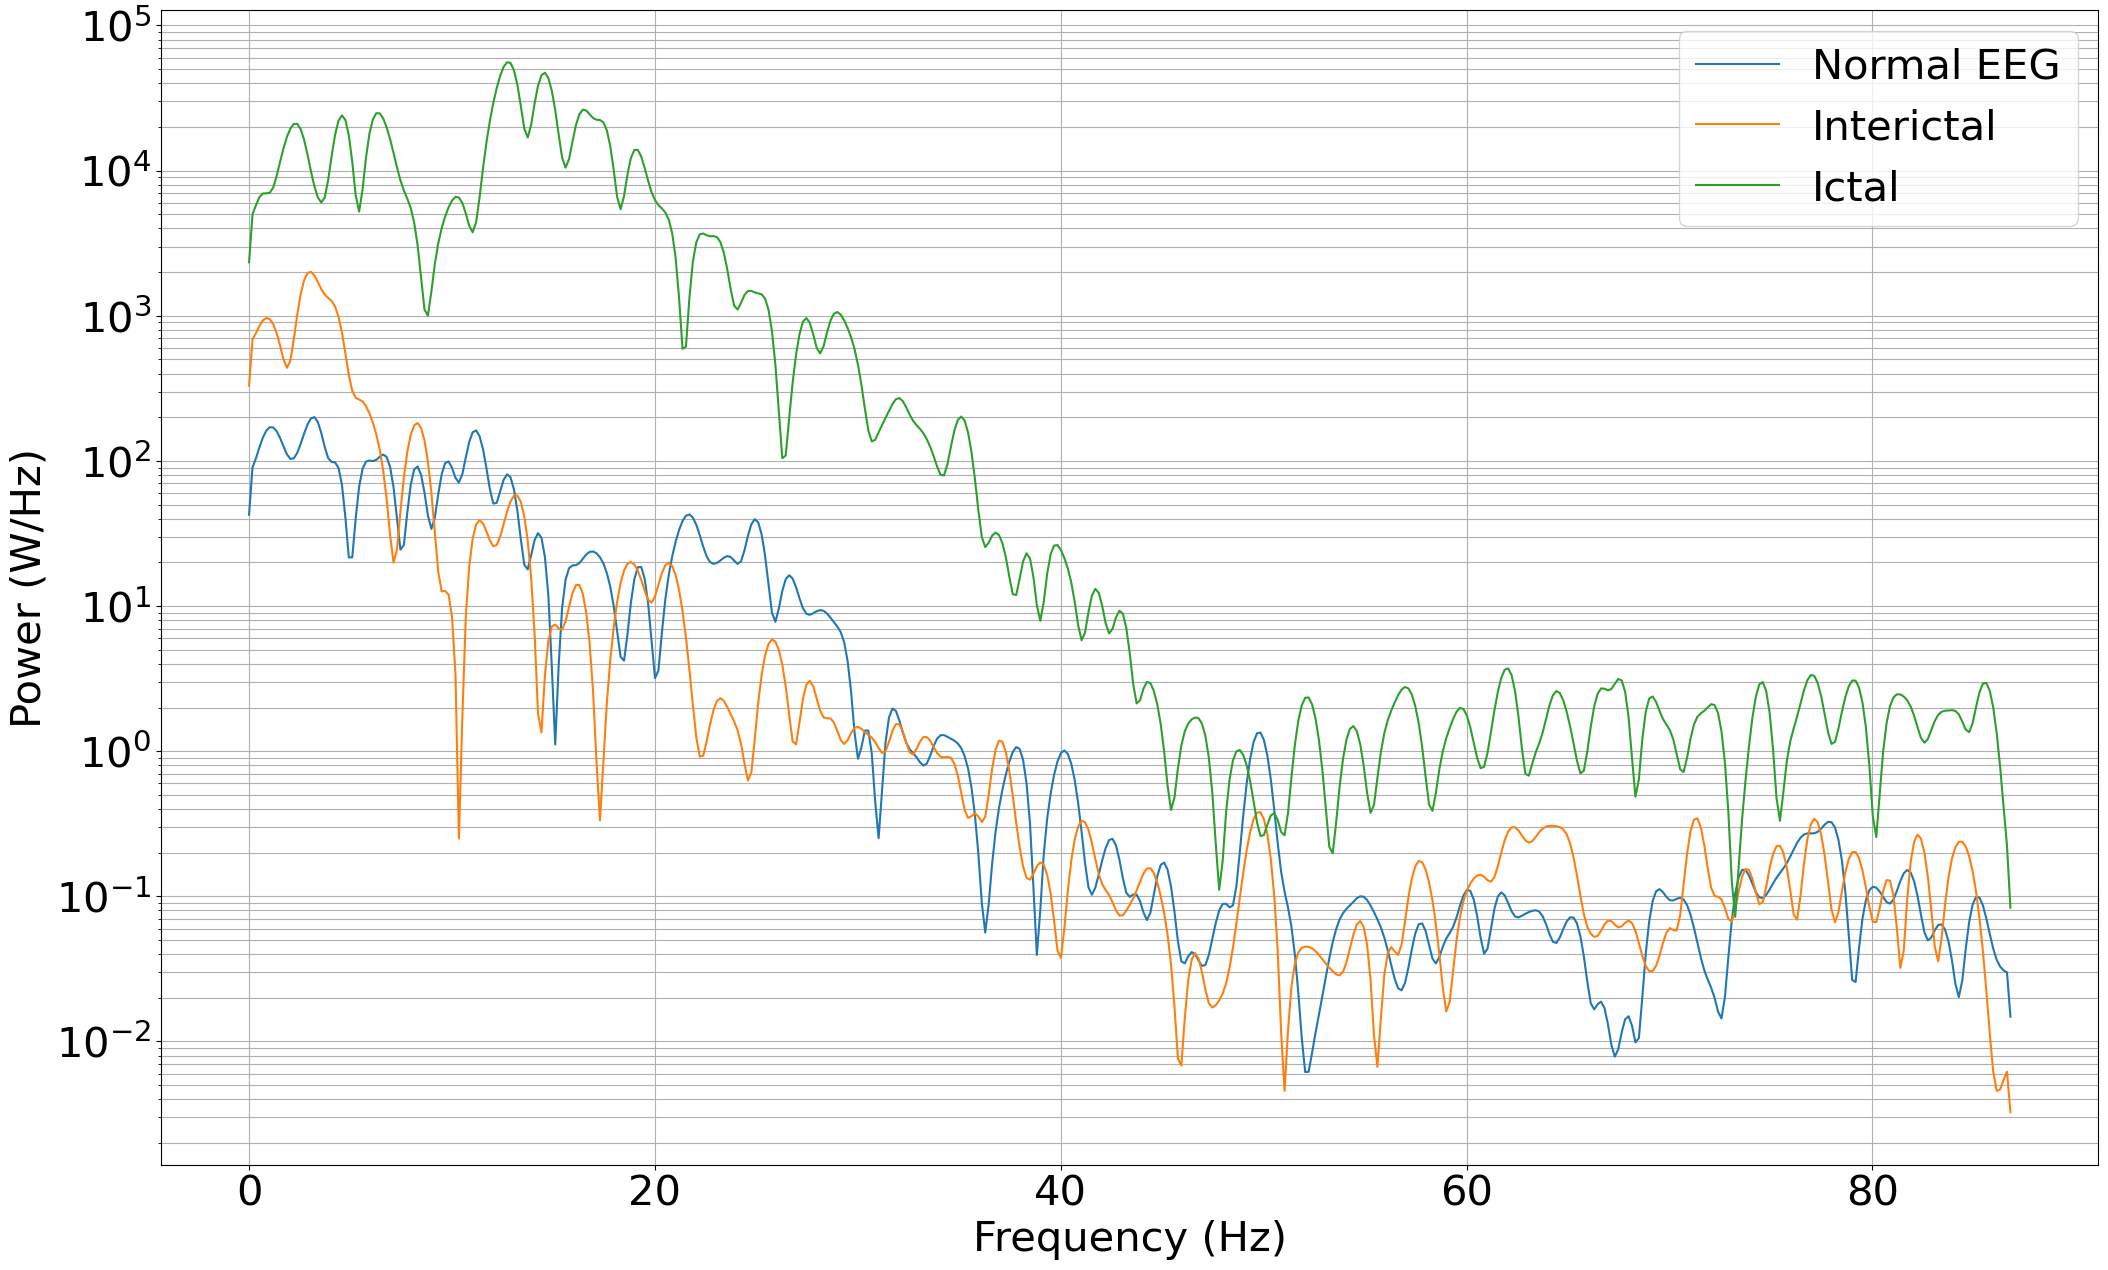

In [33]:
# Samples of estimated PSDs representing the three classes of the UoB dataset.

f1, psd1 = compute_psd(normal[index], len(normal[index]),  fs)
f2, psd2 = compute_psd(interictal[index],len(interictal[index]),   fs)
f3, psd3 = compute_psd(ictal[index],len(interictal[index]),   fs)


plt.figure(figsize=(25, 15))
plt.grid(True, which ="both")
plt.semilogy(f1, psd1, label = 'Normal EEG')
plt.semilogy(f2, psd2, label = 'Interictal')
plt.semilogy(f3, psd3, label = 'Ictal')

plt.xlabel('Frequency (Hz)', fontsize = 30)
plt.ylabel('Power (W/Hz)', fontsize = 30)
plt.tick_params(axis='both', which='major', labelsize=30)
plt.tick_params(axis='both', which='minor', labelsize= 30)
plt.legend(fontsize=30)
plt.show()

In [34]:
# Design of  a band-pass filter with pass and cut-off frequencies of 0.5 HZ and 30 Hz:

from scipy.signal import butter, filtfilt

N = 4  # Filter order. Generally, a higher order will have a steeper roll-off

# Butterworth band-pass filter design
b, a = butter(N, [0.5, 30],fs =fs,  btype='band', analog=False) # a & b are filter coefficients

In [35]:
# Filtering:
signal = X[0]

# Apply the filter to the signal
filtered_signal = filtfilt(b, a, signal)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

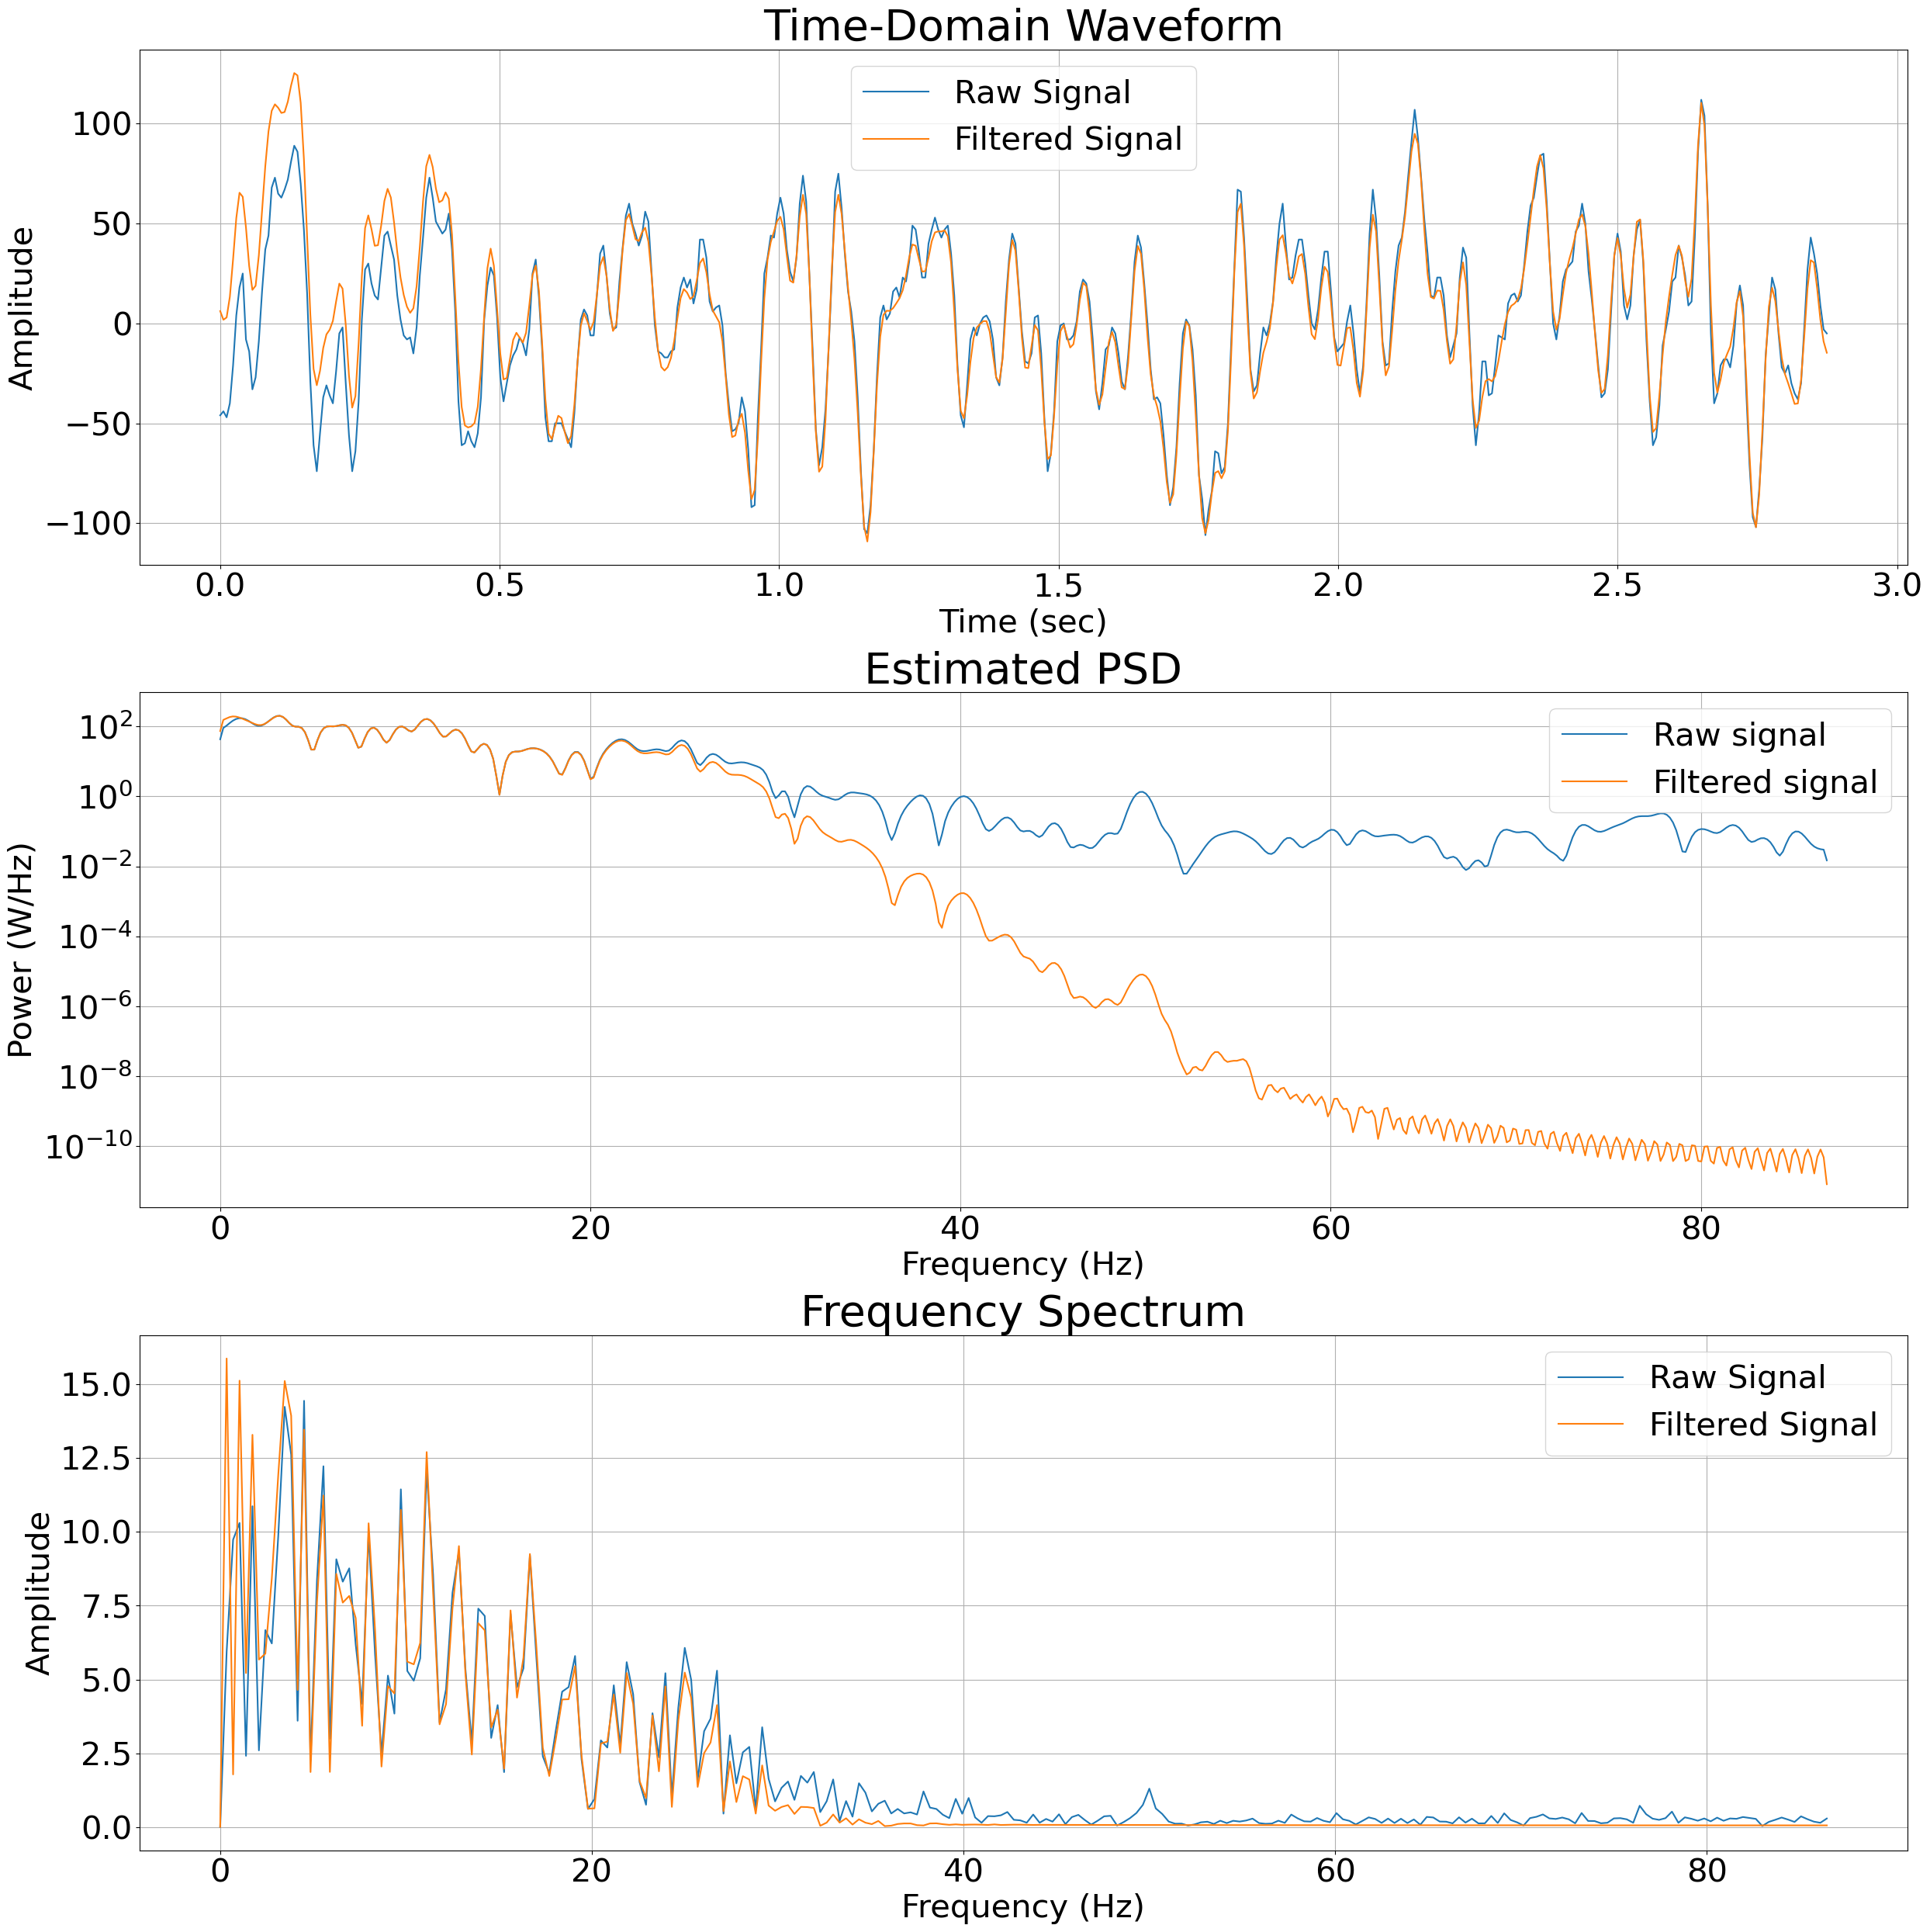

In [36]:
# A comparison between unfiltered (raw) and filtered EEG signals.

time = np.arange(0.0, len(signal), 1.0)/fs

f1, psd1 = compute_psd(signal, len(signal), fs)
f2, psd2 = compute_psd(filtered_signal,len(filtered_signal),  fs)

f_raw, x_raw = apply_fft(signal, fs)
f_lp, x_lp = apply_fft(filtered_signal, fs)

plt.figure(figsize=(25, 25))
plt.subplot(3, 1, 1)
plt.tick_params('x', labelsize=30)
plt.tick_params('y', labelsize=30)
plt.plot(time, signal, label='Raw Signal')
plt.plot(time, filtered_signal, label='Filtered Signal')
plt.xlabel('Time (sec)', fontsize = 30)
plt.ylabel('Amplitude', fontsize = 30)
plt.tick_params('x', labelsize=30)
plt.tick_params('y', labelsize=30)
plt.title('Time-Domain Waveform', fontsize = 40)
plt.legend(fontsize=30)
plt.grid(True)


plt.subplot(3, 1, 2)
plt.semilogy(f1, psd1, label = 'Raw signal')
plt.semilogy(f2, psd2, label = 'Filtered signal')
plt.xlabel('Frequency (Hz)', fontsize = 30)
plt.ylabel('Power (W/Hz)', fontsize = 30)
plt.tick_params(axis='both', which='major', labelsize=30)
plt.tick_params(axis='both', which='minor', labelsize= 30)
plt.title('Estimated PSD', fontsize = 40)
plt.legend(fontsize=30)
plt.grid(True)


plt.subplot(3, 1, 3)
plt.plot(f_raw, x_raw, label='Raw Signal')
plt.plot(f_lp, x_lp, label='Filtered Signal')
plt.xlabel('Frequency (Hz)', fontsize = 30)
plt.ylabel('Amplitude', fontsize = 30)
plt.tick_params('x', labelsize=30)
plt.tick_params('y', labelsize=30)
plt.title('Frequency Spectrum', fontsize = 40)
plt.legend(fontsize=30)
plt.grid(True)

plt.tight_layout()
plt.show()


In [37]:
# Feature calculations

num_signals = len(X)
num_features = 5
feature_matrix = np.zeros((num_signals, num_features))  # Initialize a matrix to store the features

# Loop over 10 signals
for i in range(num_signals):
    sig_in = filtfilt(b, a, X[i])
    #sig_in =X[i]
    spectral_centroid, spectral_spread, spectral_entropy, peak_freq, peak_pwr = spectral_features(sig_in, fs)
    
    # Store the features in the matrix
    feature_matrix[i, :] = [spectral_centroid, spectral_spread, spectral_entropy, peak_freq, peak_pwr]
    
print(feature_matrix.shape)

(4095, 5)


In [39]:
from skopt import Optimizer
from skopt import BayesSearchCV 
from skopt.space import Real, Categorical, Integer
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import GridSearchCV
# from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix

In [40]:
labels = Y

In [41]:
X_train, X_test, y_train, y_test = train_test_split(feature_matrix, labels, test_size = 0.3, 
                                                    shuffle = True, stratify = labels, random_state = 42)

In [42]:
X_train.shape

(2866, 5)

In [43]:
X_test.shape

(1229, 5)

In [44]:
scaler =MinMaxScaler()
train_data_scaled = scaler.fit_transform(X_train)
test_data_scaled = scaler.transform(X_test)

NameError: name 'MinMaxScaler' is not defined

In [45]:
clf_RF = RandomForestClassifier(criterion='entropy', max_features = 1, min_samples_leaf=1, min_samples_split=2, 
                                max_depth=200, n_estimators=1000, random_state= 42)
best_clf = clf_RF.fit(X_train, y_train)

In [ ]:
iso_forest = IsolationForest(
        n_estimators=1000,
        max_samples='auto',
        contamination=0.1,  # Adjust based on expected anomaly proportion
        max_features=1,
        bootstrap=False,
        n_jobs=-1,
        random_state=42,
)
iso_forest.fit(X_train)

ROC AUC = 0.992
F1 Score = 0.951179820992677
Accuracy = 95.118 %


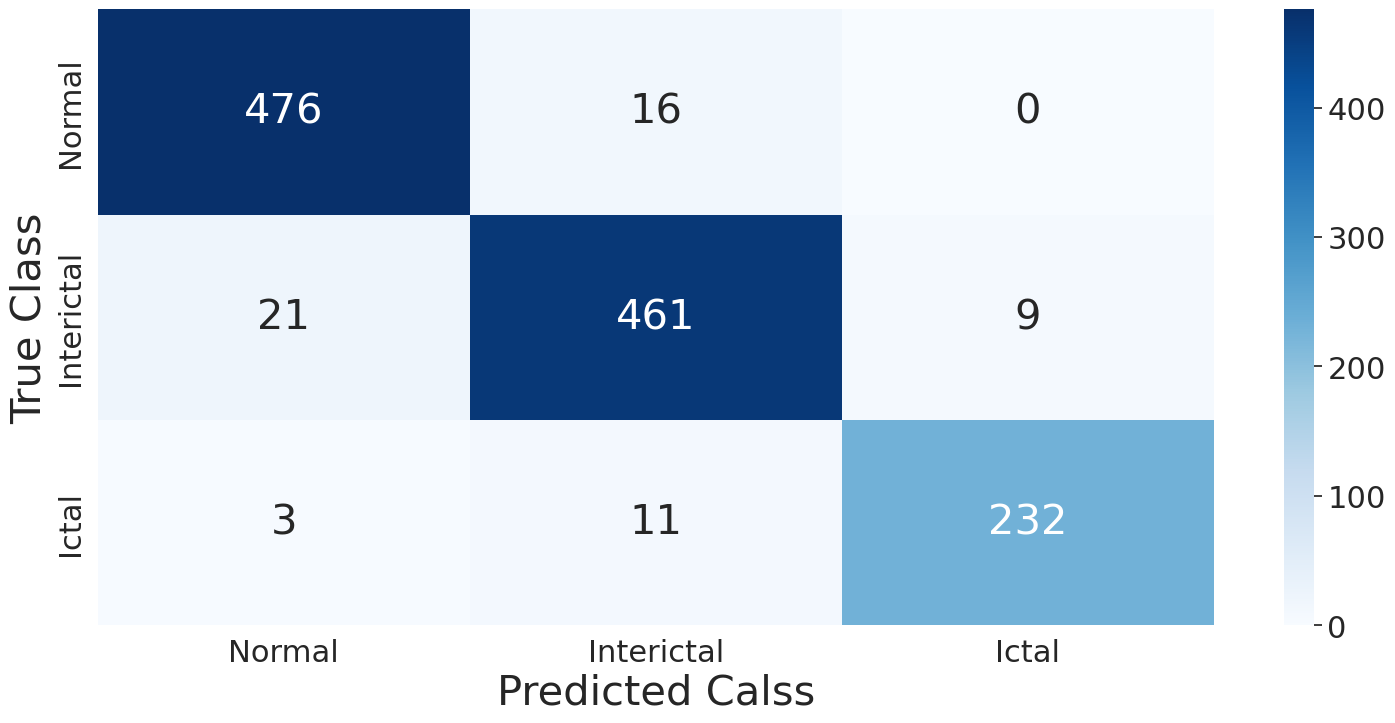

In [46]:
test_predictions = best_clf.predict(X_test)
test_confu_matrix = confusion_matrix(y_test, test_predictions)
fault_type = ['Normal','Interictal','Ictal']
plt.figure(1,figsize=(18,8))
sns.set(font_scale=2)
sns.heatmap(test_confu_matrix, annot= True,fmt = "d",
xticklabels=fault_type, yticklabels=fault_type, cmap = "Blues", annot_kws={"size": 30})
plt.xlabel('Predicted Calss', fontsize = 30)
plt.ylabel('True Class', fontsize = 30)
Accuracy = metrics.accuracy_score(y_test, test_predictions)
F1_score = metrics.f1_score(y_test, test_predictions, average='micro')
probs = best_clf.predict_proba(X_test)
lr_auc = roc_auc_score(y_test, probs, multi_class='ovr')
print('ROC AUC = %.3f' % (lr_auc))
print("F1 Score =", F1_score)
print("Accuracy = %.3f" % (Accuracy*100), "%")

Approach 1: One-vs-Rest Isolation Forest
Accuracy: 0.8641
              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88       492
         1.0       0.94      0.83      0.88       491
         2.0       0.71      0.91      0.80       246

    accuracy                           0.86      1229
   macro avg       0.85      0.87      0.86      1229
weighted avg       0.88      0.86      0.87      1229


Approach 2: Isolation Forest + Classifier
Accuracy: 0.9544
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       492
         1.0       0.95      0.94      0.95       491
         2.0       0.96      0.94      0.95       246

    accuracy                           0.95      1229
   macro avg       0.96      0.95      0.95      1229
weighted avg       0.95      0.95      0.95      1229


Original Random Forest Classifier
Accuracy: 0.9512
              precision    recall  f1-score   support

         0.0 

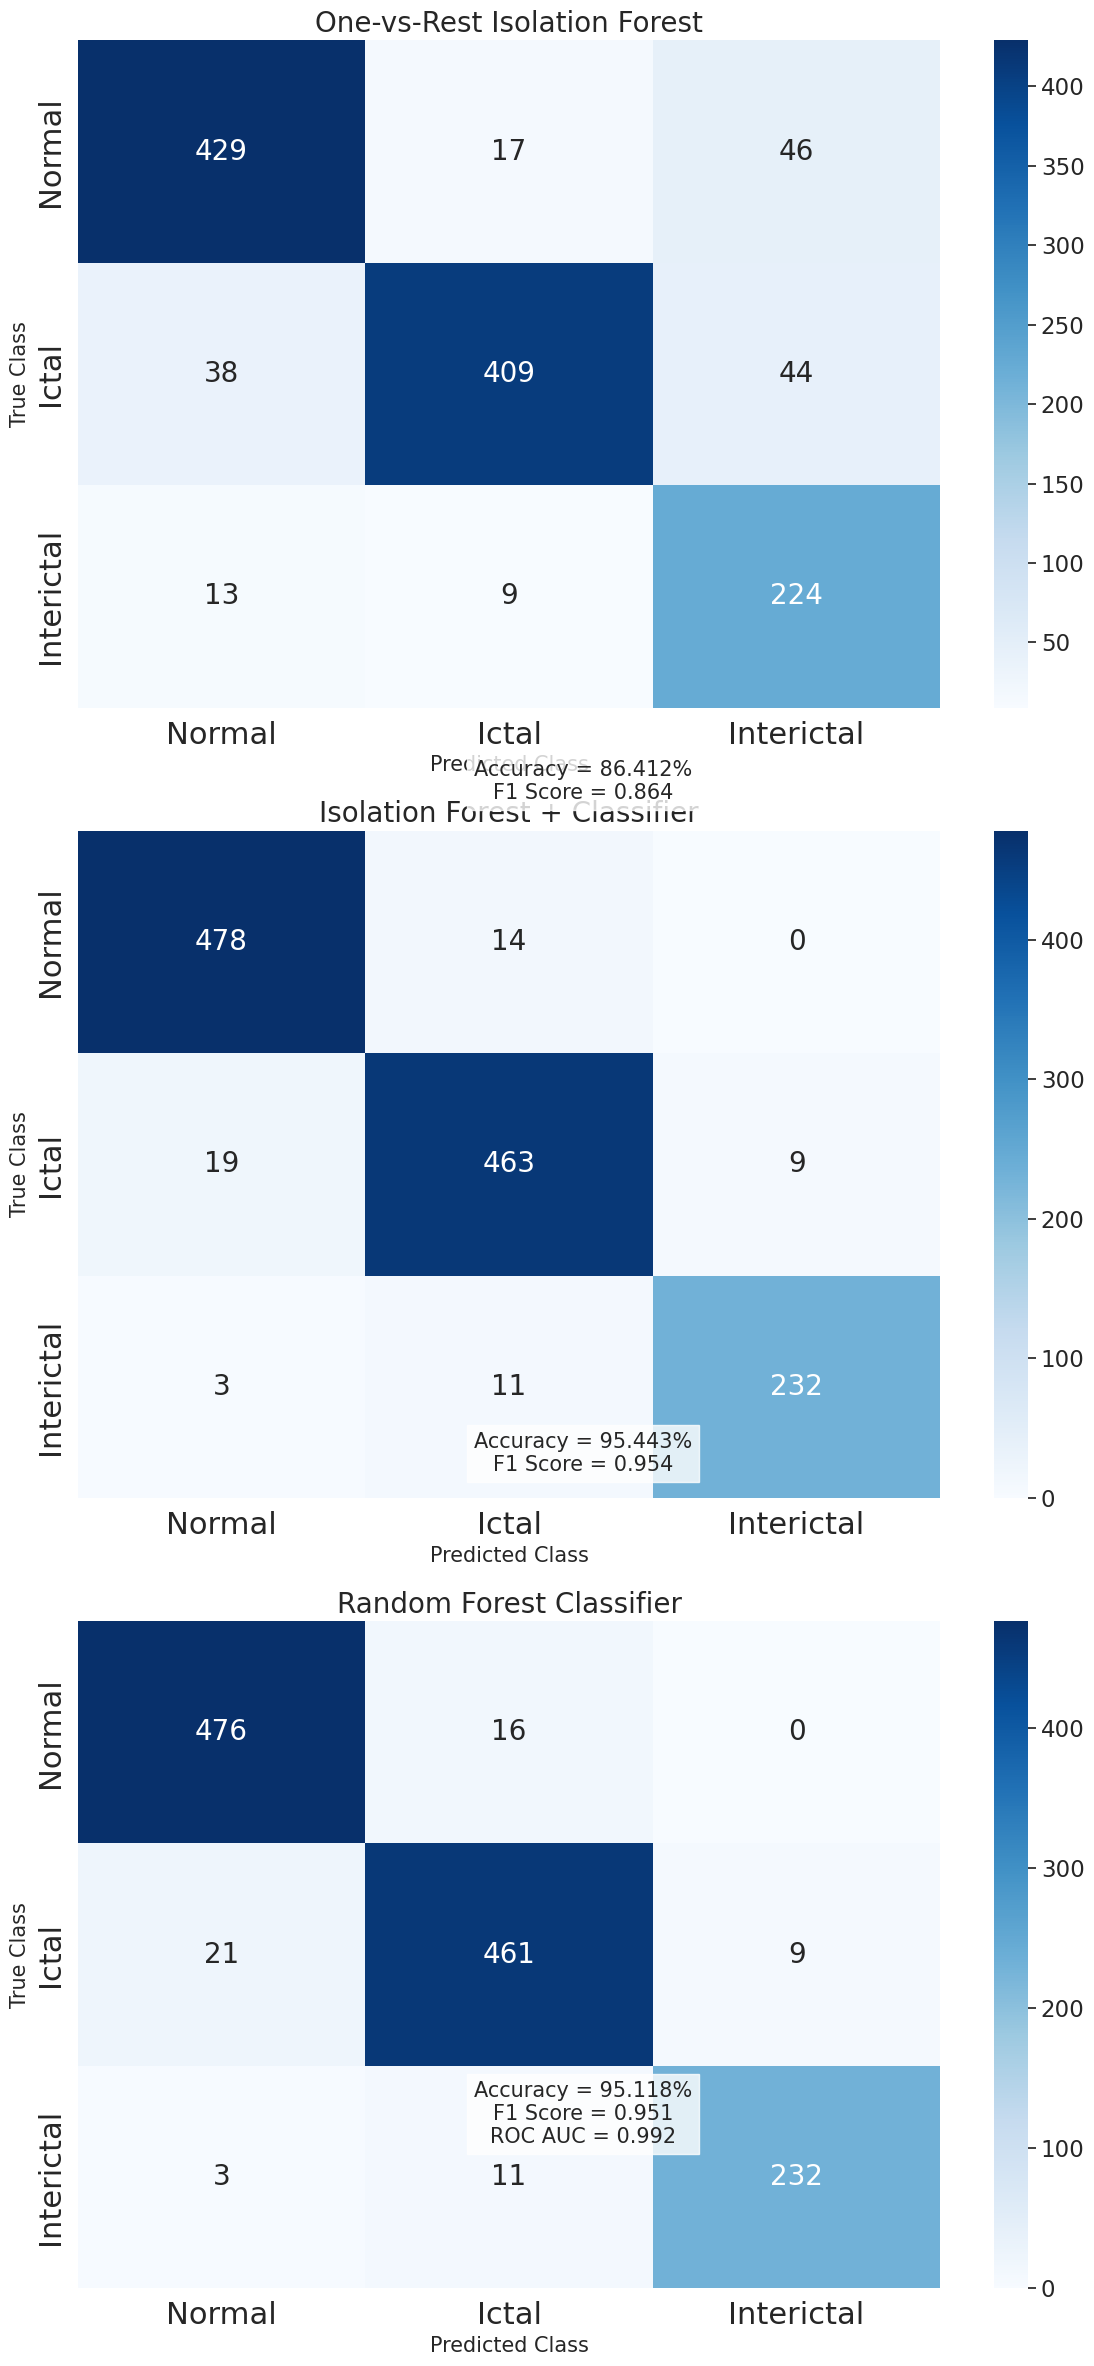

In [57]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# Approach 1: One-vs-Rest Isolation Forest
def one_vs_rest_isolation_forest(X_train, y_train, X_test, y_test, random_state=42):
    classes = np.unique(y_train)
    n_classes = len(classes)
    
    # Store predictions and anomaly scores for each class
    test_predictions = np.zeros((X_test.shape[0], n_classes))
    test_scores = np.zeros((X_test.shape[0], n_classes))
    
    # Train one model per class (treating each class as normal and others as anomalies)
    models = {}
    for i, class_label in enumerate(classes):
        # Select samples of current class
        X_train_class = X_train[y_train == class_label]
        
        # Train Isolation Forest
        iso_forest = IsolationForest(
            n_estimators=1000,
            max_samples='auto',
            contamination='auto',
            max_features=1,
            bootstrap=False,
            n_jobs=-1,
            random_state=random_state
        )
        
        iso_forest.fit(X_train_class)
        
        # Predict and get anomaly scores (-1 for outliers, 1 for inliers)
        predictions = iso_forest.predict(X_test)
        scores = iso_forest.decision_function(X_test)
        
        # Store the results
        test_predictions[:, i] = predictions
        test_scores[:, i] = scores
        models[class_label] = iso_forest
    
    # Convert predictions to class labels
    # Higher score means more likely to belong to that class
    y_pred = classes[np.argmax(test_scores, axis=1)]
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    return {
        'models': models,
        'predictions': y_pred,
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': conf_matrix,
        'raw_scores': test_scores
    }


# Approach 2: Isolation Forest for Anomaly Detection + Classification
def isolation_forest_anomaly_plus_classifier(X_train, y_train, X_test, y_test, random_state=42):
    # Train a standard Isolation Forest for anomaly detection
    iso_forest = IsolationForest(
        n_estimators=1000,
        max_samples='auto',
        contamination=0.1,  # Adjust based on expected anomaly proportion
        max_features=1,
        bootstrap=False,
        n_jobs=-1,
        random_state=random_state
    )
    
    # Fit on all training data
    iso_forest.fit(X_train)
    
    # Get anomaly scores for training and test data
    train_scores = iso_forest.decision_function(X_train)
    test_scores = iso_forest.decision_function(X_test)
    
    # Convert scores to features for classification
    X_train_with_scores = np.column_stack([X_train, train_scores])
    X_test_with_scores = np.column_stack([X_test, test_scores])
    
    # Use a Random Forest classifier with the new feature
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(
        criterion='entropy', 
        max_features=1, 
        min_samples_leaf=1, 
        min_samples_split=2,
        max_depth=200, 
        n_estimators=1000, 
        random_state=random_state
    )
    
    # Train the classifier
    clf.fit(X_train_with_scores, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test_with_scores)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    return {
        'isolation_forest': iso_forest,
        'classifier': clf,
        'predictions': y_pred,
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': conf_matrix
    }


# Example usage:
def main():
    # Assuming you already have X_train, y_train, X_test, y_test
    
    # If you need to split your data:
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Scale features (recommended for Isolation Forest)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Compare both approaches
    print("Approach 1: One-vs-Rest Isolation Forest")
    result1 = one_vs_rest_isolation_forest(X_train_scaled, y_train, X_test_scaled, y_test)
    print(f"Accuracy: {result1['accuracy']:.4f}")
    print(result1['classification_report'])
    
    print("\nApproach 2: Isolation Forest + Classifier")
    result2 = isolation_forest_anomaly_plus_classifier(X_train_scaled, y_train, X_test_scaled, y_test)
    print(f"Accuracy: {result2['accuracy']:.4f}")
    print(result2['classification_report'])
    
    # Compare with your Random Forest classifier
    from sklearn.ensemble import RandomForestClassifier
    clf_RF = RandomForestClassifier(
        criterion='entropy', 
        max_features=1, 
        min_samples_leaf=1, 
        min_samples_split=2,
        max_depth=200, 
        n_estimators=1000, 
        random_state=42
    )
    best_clf = clf_RF.fit(X_train_scaled, y_train)
    y_pred_rf = best_clf.predict(X_test_scaled)
    
    print("\nOriginal Random Forest Classifier")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
    print(classification_report(y_test, y_pred_rf))
    
    # Visualize results with confusion matrices
    fig, axes = plt.subplots(3, 1, figsize=(12, 24))
    
    # Set font scale for all plots
    sns.set(font_scale=1.5)
    
    # One-vs-Rest Isolation Forest
    plt.sca(axes[0])
    cm1 = confusion_matrix(y_test, result1['predictions'])
    sns.heatmap(cm1, annot=True, fmt="d", xticklabels=['Normal', 'Ictal', 'Interictal'], 
                yticklabels=['Normal', 'Ictal', 'Interictal'], cmap="Blues", annot_kws={"size": 20})
    plt.title("One-vs-Rest Isolation Forest", fontsize=20)
    plt.xlabel('Predicted Class', fontsize=15)
    plt.ylabel('True Class', fontsize=15)
    # Calculate metrics
    f1_1 = metrics.f1_score(y_test, result1['predictions'], average='micro')
    accuracy_1 = metrics.accuracy_score(y_test, result1['predictions'])
    plt.figtext(0.5, 0.66, f"Accuracy = {accuracy_1*100:.3f}%\nF1 Score = {f1_1:.3f}", 
                ha="center", fontsize=15, bbox={"facecolor":"white", "alpha":0.8, "pad":5})
    
    # Isolation Forest + Classifier
    plt.sca(axes[1])
    cm2 = confusion_matrix(y_test, result2['predictions'])
    sns.heatmap(cm2, annot=True, fmt="d", xticklabels=['Normal', 'Ictal', 'Interictal'], 
                yticklabels=['Normal', 'Ictal', 'Interictal'], cmap="Blues", annot_kws={"size": 20})
    plt.title("Isolation Forest + Classifier", fontsize=20)
    plt.xlabel('Predicted Class', fontsize=15)
    plt.ylabel('True Class', fontsize=15)
    # Calculate metrics
    f1_2 = metrics.f1_score(y_test, result2['predictions'], average='micro')
    accuracy_2 = metrics.accuracy_score(y_test, result2['predictions'])
    plt.figtext(0.5, 0.38, f"Accuracy = {accuracy_2*100:.3f}%\nF1 Score = {f1_2:.3f}", 
                ha="center", fontsize=15, bbox={"facecolor":"white", "alpha":0.8, "pad":5})
    
    # Random Forest
    plt.sca(axes[2])
    cm3 = confusion_matrix(y_test, y_pred_rf)
    sns.heatmap(cm3, annot=True, fmt="d", xticklabels=['Normal', 'Ictal', 'Interictal'], 
                yticklabels=['Normal', 'Ictal', 'Interictal'], cmap="Blues", annot_kws={"size": 20})
    plt.title("Random Forest Classifier", fontsize=20)
    plt.xlabel('Predicted Class', fontsize=15)
    plt.ylabel('True Class', fontsize=15)
    # Calculate metrics
    f1_3 = metrics.f1_score(y_test, y_pred_rf, average='micro')
    accuracy_3 = metrics.accuracy_score(y_test, y_pred_rf)
    # Try to calculate ROC AUC if proba predictions are available
    try:
        probs_rf = best_clf.predict_proba(X_test_scaled)
        roc_auc = metrics.roc_auc_score(y_test, probs_rf, multi_class='ovr')
        plt.figtext(0.5, 0.10, f"Accuracy = {accuracy_3*100:.3f}%\nF1 Score = {f1_3:.3f}\nROC AUC = {roc_auc:.3f}", 
                    ha="center", fontsize=15, bbox={"facecolor":"white", "alpha":0.8, "pad":5})
    except:
        plt.figtext(0.5, 0.10, f"Accuracy = {accuracy_3*100:.3f}%\nF1 Score = {f1_3:.3f}", 
                    ha="center", fontsize=15, bbox={"facecolor":"white", "alpha":0.8, "pad":5})
    
    plt.tight_layout(h_pad=1.0)
    plt.show()

if __name__ == "__main__":
    main()